# Example: Updating Single-Asset GBM Parameters with EMA
The [out-of-sample example](CHEME-5660-L5a-Example-OOS-SAGBM-Fall-2026.ipynb) keeps the fitted GBM parameters fixed throughout 2025. What happens if we give recent observations more weight as new prices arrive? In this example, we use an exponential moving average (EMA) to update mean growth and volatility, then compare the resulting forecasts with the frozen model.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Update mean growth and volatility:** Initialize the mean and variance of growth rates from the 2014–2024 estimates and update them using exponential weights. Explain how the half-life determines the influence of recent observations.
> * **Construct forecasts with updated estimates:** Use only observations available at each forecast date and hold the parameter estimates fixed over the chosen forward window. Compare simulations and target probabilities using frozen estimates, updated volatility, and updated mean growth with volatility.
> * **Evaluate whether updating helps:** Compare the methods on the same observed outcomes using the coverage of their 95% prediction bands. Distinguish estimates that respond to new observations from estimates that improve predictions.

We use the NPV target from the [trade-rule example](CHEME-5660-L5a-Example-GBM-NPV-TradeRule-Fall-2026.ipynb) to evaluate the forecasts. The original purchase remains fixed while we assess possible sale dates a chosen number of trading observations ahead. The entry index, forward window, benchmark, and EMA half-life are adjustable.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, loads the required packages, and includes local helper code.

Let's set up our code environment:

In [1]:
# Load the course environment and the local EMA and forecast-comparison helpers -
include(joinpath(@__DIR__, "Include.jl")); # resolve the setup file from this notebook's directory

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [course package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here. The local [adaptive-forecast function reference](docs/adaptive-functions.md) links to the documented source helpers.

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 2, 2025 until December 31, 2025, along with data for several exchange-traded funds and volatility products during that time period.

Let's load the `original_dataset::Dict{String,DataFrame}` by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet).

In [2]:
# Load held-out 2025 prices; fitted parameters will come from the earlier training period -
original_dataset = MyTestingMarketDataSet() |> x -> x["dataset"]; # load the testing data by ticker

Now, let's load the GBM parameters estimated from the 2014 to 2024 training data in [the L4b parameter-estimation example](../../week-4/L4b/CHEME-5660-L4b-Example-Parameters-SAGBM-Fall-2026.ipynb). We store the table in the `parameters_df::DataFrame` variable. The legacy `drift` column contains the mean growth rate estimate $\hat{\mu}_g$, and the `volatility` column contains $\hat{\sigma}$. We will convert mean growth to arithmetic GBM drift when we build the model.

In [3]:
parameters_df = let

    # Load the saved 2014–2024 estimates -
    # The legacy drift column is mean growth μ̂_g; the model needs μ̂_g + σ̂²/2.
    df = CSV.read(joinpath(_PATH_TO_DATA,"SAGBM-Parameters-Fall-2025.csv"), DataFrame);
    df; # retain ticker names so subsequent lookups do not depend on CSV row order
end;

### Match the Training Estimates and Testing Histories
The training parameter table and testing dataset contain different sets of tickers. We need both fitted parameters and a complete price history on the common 2025 date grid. 

The [eligible_gbm_data(...) function](docs/adaptive-functions.md#eligible_gbm_data) checks alignment, positive prices, and valid estimates. It returns the eligible tickers and a table explaining every exclusion. So what is our eligible universe?

In [4]:
# Match parameters and complete testing histories by ticker and actual date -
eligible = eligible_gbm_data(original_dataset, parameters_df);
dataset = eligible.dataset; # ticker → aligned 2025 prices
list_of_tickers = eligible.tickers; # common selectable and evaluated universe
observation_dates = eligible.dates; # the same date grid for every retained ticker
exclusions_df = eligible.exclusions; # retain every excluded ticker and its reason
println("Eligible tickers: $(length(list_of_tickers)); observations per ticker: $(length(observation_dates))")
println("Date range: $(Date(first(observation_dates))) to $(Date(last(observation_dates)))")
pretty_table(combine(groupby(exclusions_df, :reason), nrow => :count));


Eligible tickers: 417; observations per ticker: 250
Date range: 2025-01-02 to 2025-12-31
┌───────────────────────────────────────┬───────┐
│                                reason │ count │
│                                String │ Int64 │
├───────────────────────────────────────┼───────┤
│                  No training estimate │    59 │
│ Incomplete or unaligned testing dates │     7 │
└───────────────────────────────────────┴───────┘


The count table describes exclusions from the union of testing tickers and parameter-table tickers. The full `exclusions_df` remains available for inspection.

In [5]:
eligible.exclusions

Row,ticker,reason
,String,String
1,AMCR,No training estimate
2,ANET,No training estimate
3,ANSS,Incomplete or unaligned testing dates
4,APTV,No training estimate
5,ARKK,No training estimate
6,BBWI,No training estimate
7,BIIB,No training estimate
8,BKNG,No training estimate
9,BKR,No training estimate


__Constants.__ Let's set some constants that we'll use in this study. See the comment next to each constant for its definition and units:

In [6]:
# Choose one asset and one original purchase, then reuse them throughout -
ticker_to_simulate = "SPY"; # editable example ticker
start_day_index = 1; # one-based purchase and first forecast row in the aligned 2025 data
holding_period_days = 21; # forward trading intervals; 1 means the next observation
Δt = 1/252; # years per trading interval
g_y = 0.05; # annual continuously compounded benchmark growth rate (1/year)
rho_star = 0.0; # target scaled NPV; zero means beating the benchmark
ema_half_life_days = 21; # observations required to halve an older observation's weight
half_lives_to_compare = [1, 5, 21, 63]; # half-lives overlaid in the Task 1 figure; only the default flows into Tasks 2 and 3
λ = 2.0^(-1/ema_half_life_days); # decay per observation, separate from the forecast window
number_of_paths = 100; # simulated paths shown in price figures
random_seed = 5660; # reproduce the simulations
Random.seed!(random_seed);
date_ticks = let # mid-month tick marks shared by the figures with dates on the horizontal axis
    d0 = Date(first(observation_dates)); d1 = Date(last(observation_dates));
    t = collect(Date(year(d0), month(d0), 15):Month(1):d1);
    (t, Dates.format.(t, "u d"))
end;
ticks_through(d) = (date_ticks[1][date_ticks[1] .<= d], date_ticks[2][date_ticks[1] .<= d]); # drop ticks past the last plotted date

# Validate the entry and complete forward window rather than silently clipping dates -
@assert ticker_to_simulate in list_of_tickers "Select an eligible ticker"
@assert start_day_index isa Integer && start_day_index >= 1 "Use a positive integer start index"
@assert holding_period_days isa Integer && holding_period_days >= 1 "Use a positive integer holding period"
@assert start_day_index + holding_period_days <= length(observation_dates) "The full holding window must be observed"
@assert number_of_paths > 0 "The simulation count must be positive"
first_sale_index = start_day_index + holding_period_days;
random_firm_data = dataset[ticker_to_simulate];
prices = Float64.(random_firm_data.volume_weighted_average_price);
println("$(ticker_to_simulate): buy $(Date(observation_dates[start_day_index])); first prospective sale $(Date(observation_dates[first_sale_index]))")

SPY: buy 2025-01-02; first prospective sale 2025-02-04


___

## Task 1: Update Mean Growth and Volatility
In this task, we initialize the parameter estimates from the training period, update them as each 2025 price is observed, and plot how they change relative to the baseline for several half-lives.

__Why update parameters if GBM assumes they are constant?__ We use GBM as a local forecast model. Its parameters remain fixed over each forecast window, then we fit a new local model after another observation arrives. Updating can respond to observed changes, but it cannot anticipate the next unobserved shock.

> __Proposition: Exponentially Weighted GBM Estimates__
>
> Let $g_k=\ln(S_k/S_{k-1})/\Delta t$ be the observed growth rate ($\mathrm{year}^{-1}$), with positive price observations spaced $\Delta t>0$ years apart. At entry index $s$, initialize its mean and variance from the training estimates: $m_s=\hat\mu_{g,0}$ and $v_s=\hat\sigma_0^2/\Delta t$.
>
> For a decay factor $0<\lambda<1$ and each new observation $k>s$, the weighted moments and corresponding GBM estimates satisfy:
>
> $$
> \begin{aligned}
> \delta_k&=g_k-m_{k-1}, &&\text{(innovation)}\\
> m_k&=m_{k-1}+(1-\lambda)\delta_k, &&\text{(mean update)}\\
> v_k&=\lambda\left[v_{k-1}+(1-\lambda)\delta_k^2\right], &&\text{(variance update)}\\[4pt]
> \hat\mu_{g,k}&=m_k,\qquad
> \hat\sigma_k=\sqrt{v_k\Delta t},\qquad
> \hat\mu_k=\hat\mu_{g,k}+\frac12\hat\sigma_k^2. &&\text{(GBM parameters)}
> \end{aligned}
> $$
>
> Here, $m_k$ and $v_k$ are the weighted mean ($\mathrm{year}^{-1}$) and variance ($\mathrm{year}^{-2}$) of growth rates; $\hat\mu_{g,k}$, $\hat\sigma_k$, and $\hat\mu_k$ are mean growth, volatility, and drift. The variance accounts for the changing mean and has no finite-sample unbiased correction.
>
> __Where is this coming from?__
>
> [▶ Derivation of the EMA parameter updates](advanced/ema-derivation/CHEME-5660-L5a-Derivation-EMA-SAGBM-Fall-2026.ipynb). Why does the variance update contain an extra factor of $\lambda$? We derive the exponential weights, centered variance, and conversion to GBM parameters.

Here, $\lambda=2^{-1/H_{\mathrm{half}}}$ and $H_{\mathrm{half}}$ is the half-life in trading observations: an observation's weight halves after that many further observations. With the default 21-observation half-life, $\lambda\approx0.9675$, so the updated mean assigns about 96.75% weight to the previous mean and 3.25% to the newest growth-rate observation.

The [ema_gbm_parameters(...) function](docs/adaptive-functions.md#ema_gbm_parameters) begins with the growth rate observed from row $s$ to row $s+1$. Changing the start index resets this experiment's initialization. A shorter half-life gives more weight to recent changes but can make the estimated mean growth especially noisy.

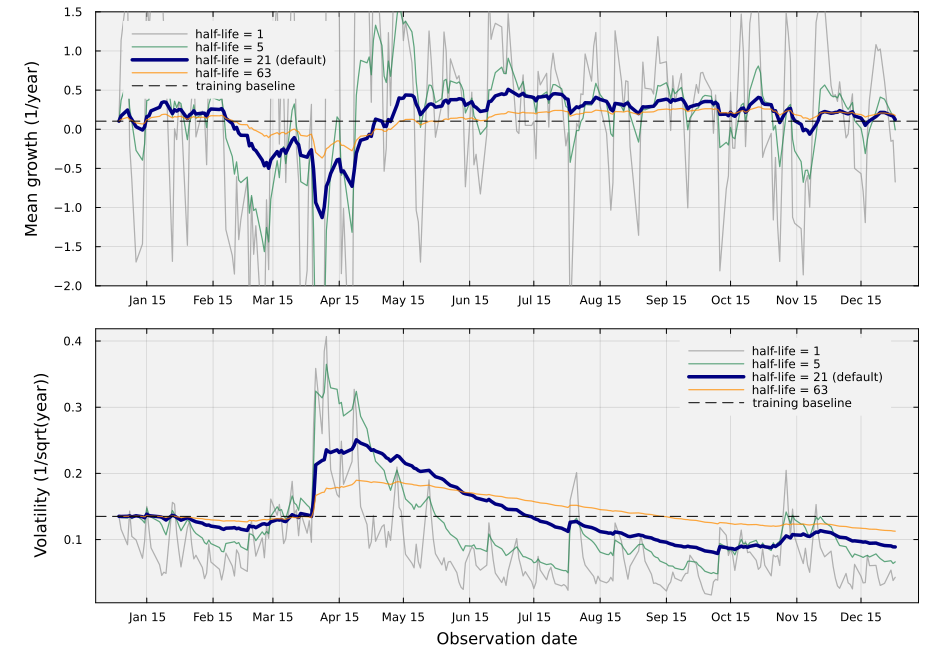

In [7]:
# Read the selected ticker's training baseline; do not fit it to 2025 prices -
parameter_row = findfirst(==(ticker_to_simulate), parameters_df.ticker);
baseline_mu_g = parameters_df.drift[parameter_row]; # training mean growth (1/year)
baseline_sigma = parameters_df.volatility[parameter_row]; # training volatility (1/sqrt(year))
# Follow the selected ticker's causal parameter states -
parameter_states = ema_gbm_parameters(prices, baseline_mu_g, baseline_sigma;
    start_index=start_day_index, dt=Δt, half_life=ema_half_life_days);
let
    # Overlay the same updates for several half-lives; the default is drawn thicker -
    colors = [:gray60, :seagreen, :navy, :darkorange]; # default drawn thick in navy
    p1 = plot(; ylabel="Mean growth (1/year)", legend=:topleft, ylims=(-2.0,1.5), legendfontsize=8, xticks=date_ticks); # clip so the longer half-lives stay legible
    p2 = plot(; ylabel="Volatility (1/sqrt(year))", xlabel="Observation date", legend=:topright, legendfontsize=8, xticks=date_ticks);
    for (i,H) in enumerate(half_lives_to_compare)
        states = (H == ema_half_life_days) ? parameter_states :
            ema_gbm_parameters(prices, baseline_mu_g, baseline_sigma;
                start_index=start_day_index, dt=Δt, half_life=H);
        dates = Date.(observation_dates[states.index]);
        lw = (H == ema_half_life_days) ? 3.5 : 1.25; # emphasize the default used downstream
        alpha = (H == ema_half_life_days) ? 1.0 : 0.75;
        label = (H == ema_half_life_days) ? "half-life = $(H) (default)" : "half-life = $(H)";
        plot!(p1, dates, states.mu_g; label, c=colors[mod1(i,length(colors))], lw, alpha);
        plot!(p2, dates, states.sigma; label, c=colors[mod1(i,length(colors))], lw, alpha);
    end
    hline!(p1, [baseline_mu_g]; label="training baseline", c=:black, ls=:dash);
    hline!(p2, [baseline_sigma]; label="training baseline", c=:black, ls=:dash);
    p = plot(p1,p2; layout=(2,1), size=(950,650), left_margin=8Plots.mm, right_margin=6Plots.mm,
        bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent);
    savefig(p, joinpath(_PATH_TO_FIGS,"L5a-ema-parameters.png"));
    p
end

__What do we see?__ The four curves in each panel respond to the same observations; the half-life sets how strongly.
* __Mean growth__: The one-observation estimate swings past the clipped axis from one day to the next. The default 21-observation estimate falls to about $-1$ per year in the April 2025 drop and recovers within a month, while the 63-observation estimate barely leaves the training baseline.
* __Volatility__: The shorter the half-life, the larger the jump when the April shock arrives and the faster the estimate decays afterward. Between shocks, the two shortest half-lives sit below the training baseline for most of the year.

A moving estimate alone is not evidence of a better forecast. We need to record its probability and check that probability against the later outcome.

___

## Task 2: Compare Frozen and EMA Forecasts
In this task, we compare three ways of setting the GBM parameters on each forecast date: frozen training estimates, EMA volatility with frozen mean growth, and EMA mean growth with EMA volatility.

__Setup.__ We buy once, on the entry date with index $s$ in the 2025 price data set, at price $S_s$, and hold for the remainder of the year. On each later date $k>s$, we ask: what is the probability that selling $H$ trading days from now beats the NPV target? 

Two time spans are now important: the forecast horizon $h$ from the forecast date to the sale, and the discounting span $T_k$ from the purchase to that same sale. Both are expressed in years:

$$
h=H\Delta t,\qquad T_k=(k+H-s)\Delta t.
$$

The forecast horizon $h$ runs from the forecast date to the sale; the discounting span $T_k$ runs from the purchase to the same sale (both in years).

__Forecast.__ For a benchmark growth rate $g_y$ and a target $\rho_\star>-1$, the [trade-rule example](CHEME-5660-L5a-Example-GBM-NPV-TradeRule-Fall-2026.ipynb) gives the sale price at which the scaled NPV equals the target, and the probability of exceeding it:

$$
\begin{aligned}
K_k&=S_s(1+\rho_\star)e^{g_yT_k}, &&\text{(sale threshold)}\\
p_k&=1-\Phi\!\left(\frac{\ln(K_k/S_k)-\hat\mu_{g,k}h}{\hat\sigma_k\sqrt h}\right). &&\text{(target probability)}
\end{aligned}
$$

Here, $S_k$ is the price on the forecast date, $\hat\mu_{g,k}$ and $\hat\sigma_k>0$ are the mean growth and volatility estimates available on that date (which depend on the method), and $\Phi$ is the standard normal cumulative distribution function. We hold the parameters fixed within each forecast.

[The rolling_trade_forecasts(...) function](docs/adaptive-functions.md#rolling_trade_forecasts) records forecasts; [the score_trade_forecasts(...) function](docs/adaptive-functions.md#score_trade_forecasts) attaches later outcomes.


In [8]:
rolling_results = let
    tables = DataFrame[]; # each ticker contributes identical origins and three forecasting methods
    for ticker in list_of_tickers
        j = findfirst(==(ticker), parameters_df.ticker);
        asset_prices = Float64.(dataset[ticker].volume_weighted_average_price);
        forecasts = rolling_trade_forecasts(asset_prices, observation_dates,
            parameters_df.drift[j], parameters_df.volatility[j]; ticker,
            start_index=start_day_index, holding_days=holding_period_days, dt=Δt,
            half_life=ema_half_life_days, benchmark=g_y, target=rho_star);
        push!(tables, score_trade_forecasts(forecasts, asset_prices)); # attach later outcomes separately
    end
    reduce(vcat,tables)
end;
selected_results = rolling_results[rolling_results.ticker .== ticker_to_simulate, :];
method_order = ["Frozen", "EMA volatility", "EMA mean + volatility"];
println("Forecast origins per ticker and method: $(nrow(selected_results) ÷ 3)")
println("Every sale lies within the observed 2025 data; the purchase remains at row $(start_day_index).")


Forecast origins per ticker and method: 229
Every sale lies within the observed 2025 data; the purchase remains at row 1.


Plot the probabilities and later sale outcomes for the selected ticker, using forecast dates on the horizontal axis.


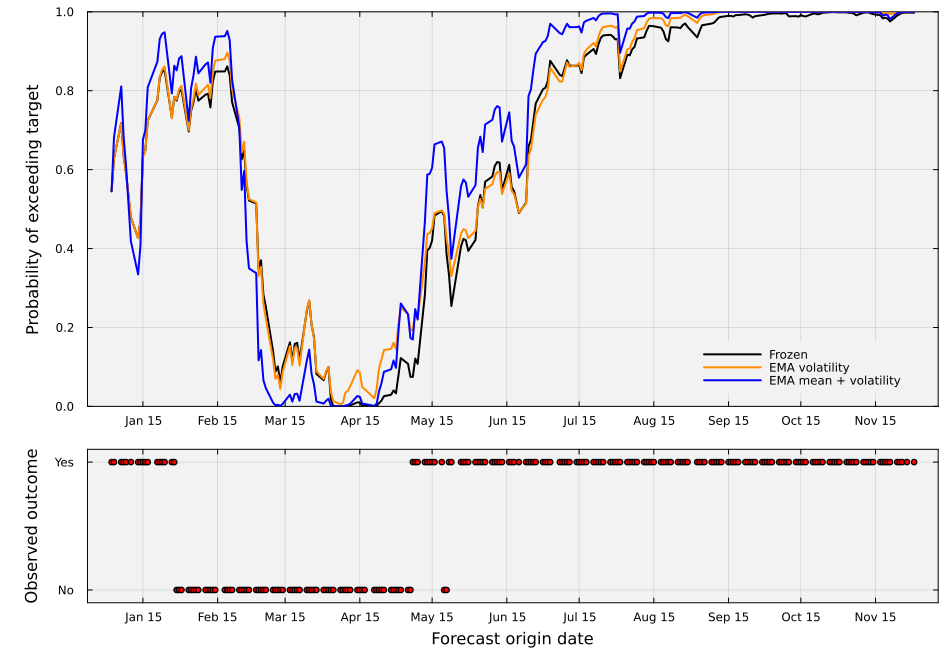

In [9]:
let
    colors = [:black, :darkorange, :blue];
    origin_ticks = ticks_through(Date(maximum(selected_results.origin_date)));
    p1 = plot(; ylabel="Probability of exceeding target", ylim=(0,1), legend=:bottomright, xticks=origin_ticks);
    for (i,method) in enumerate(method_order)
        rows = selected_results[selected_results.method .== method, :];
        plot!(p1, Date.(rows.origin_date), rows.probability; label=method, c=colors[i], lw=2);
    end
    rows = selected_results[selected_results.method .== "Frozen", :];
    p2 = scatter(Date.(rows.origin_date), Int.(rows.target_met); label="later sale exceeded target",
        c=:red, ms=3, ylabel="Observed outcome", yticks=([0,1],["No","Yes"]),
        ylim=(-0.1,1.1), xlabel="Forecast origin date", legend=false, xticks=origin_ticks);
    p = plot(p1,p2; layout=grid(2,1,heights=[0.72,0.28]), size=(950,650), left_margin=8Plots.mm,
        bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent);
    savefig(p, joinpath(_PATH_TO_FIGS,"L5a-rolling-probabilities.png"));
    p
end


The methods give the same forecast at entry. Later probabilities change with prices, sale dates, and EMA estimates; the original purchase stays fixed.

### Simulate an Updated Forecast
Choose a date near the middle of the available forecasts. Use [the sample(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.sample-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}) to simulate each model from that day's price using the exact GBM transition. As in the [out-of-sample example](CHEME-5660-L5a-Example-OOS-SAGBM-Fall-2026.ipynb), each panel shows the lognormal 68%, 95%, and 99% prediction bands, the expectation and median, the simulated paths, and the observed prices (red), plus the sale target. The three figures share random draws and price limits.


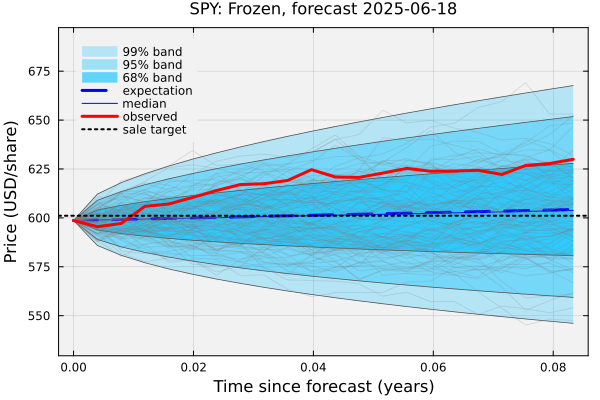

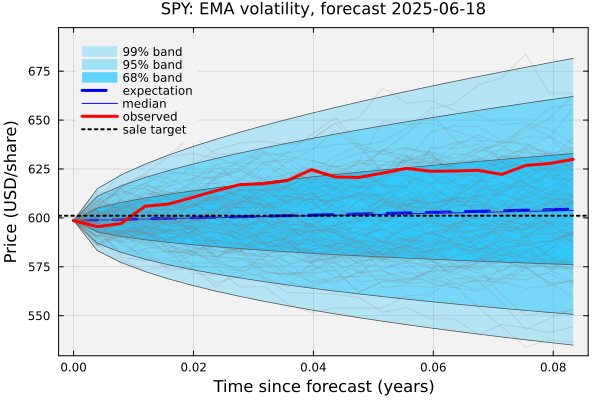

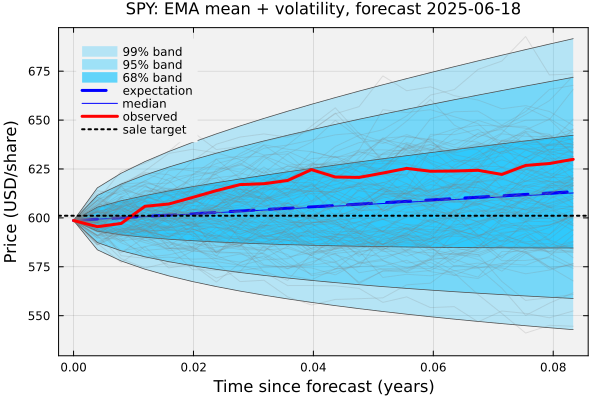

In [10]:
let
    # Select a valid origin automatically when the entry or holding period changes -
    origin = start_day_index + (length(prices)-holding_period_days-start_day_index) ÷ 2;
    rows = selected_results[selected_results.origin_index .== origin, :];
    panels = [];
    for method in method_order
        row = only(eachrow(rows[rows.method .== method, :]));
        μ̂_g, σ̂ = row.mu_g, row.sigma; # estimates available on the forecast date (1/year, 1/sqrt(year))
        μ̂ = μ̂_g + 0.5*σ̂^2; # GBM drift (1/year)
        local_model = build(MyGeometricBrownianMotionEquityModel, (μ=μ̂, σ=σ̂));
        Random.seed!(random_seed); # common random inputs make the model comparison easier to see
        paths = VLQuantitativeFinancePackage.sample(local_model,
            (Sₒ=row.current_price,T₁=0.0,T₂=holding_period_days*Δt,Δt=Δt);
            number_of_paths=number_of_paths);

        # Lognormal bands, expectation, and median from the forecast-date estimates -
        τ = paths[:,1]; # elapsed time from the forecast date (years)
        median_value = row.current_price*exp.(μ̂_g*τ); # lognormal median price (USD/share)
        expected_value = row.current_price*exp.(μ̂*τ); # expected price (USD/share)
        (L68,U68) = gbm_prediction_band(median_value, σ̂, τ; z=1.0);
        (L95,U95) = gbm_prediction_band(median_value, σ̂, τ; z=1.96);
        (L99,U99) = gbm_prediction_band(median_value, σ̂, τ; z=2.576);

        # Draw the widest band first so the narrower bands remain visible on top -
        p = plot(τ, U99; fillrange=L99, c=:deepskyblue1, alpha=0.25, label="99% band", lw=0,
            title="$(ticker_to_simulate): $(method), forecast $(Date(observation_dates[origin]))", titlefontsize=11,
            xlabel="Time since forecast (years)", ylabel="Price (USD/share)", legend=:topleft);
        plot!(p, τ, U95; fillrange=L95, c=:deepskyblue1, alpha=0.35, label="95% band", lw=0);
        plot!(p, τ, U68; fillrange=L68, c=:deepskyblue1, alpha=0.6, label="68% band", lw=0);
        plot!(p, τ, [L99 U99 L95 U95 L68 U68]; c=:gray30, lw=0.75, label=""); # thin borders on the band edges
        plot!(p, τ, expected_value; c=:blue, lw=3, ls=:dash, label="expectation");
        plot!(p, τ, median_value; c=:blue, lw=1, label="median");
        plot!(p, τ, paths[:,2:end]; label=false, c=:gray50, lw=1, alpha=0.2);
        plot!(p, τ, prices[origin:origin+holding_period_days]; label="observed", c=:red, lw=3);
        hline!(p, [row.threshold]; label="sale target", c=:black, ls=:dot, lw=2);
        push!(panels,p);
    end
    # Give all three figures identical price limits so their spreads can be compared -
    limits = ylims.(panels);
    common_limits = (minimum(first.(limits)), maximum(last.(limits)));
    for (method, panel) in zip(method_order, panels)
        plot!(panel; ylims=common_limits, bg="gray95", background_color_outside="white",
            framestyle=:box, fg_legend=:transparent);
        savefig(panel, joinpath(_PATH_TO_FIGS,"L5a-updated-simulation-$(replace(lowercase(method), " " => "-", "+" => "and")).png"));
        display(panel);
    end
end


Compare the final prices with the sale target. Volatility changes the spread; mean growth shifts the median. One path cannot establish which method predicts better.

___

## Task 3: Evaluate Whether Updating Helps
In this task, we ask whether updating the parameters gives a better forecast distribution. Over a 21-day window, the drift term $\hat\mu_{g}h$ is small compared with the volatility term $\hat\sigma\sqrt{h}$, so the probability of beating the benchmark is near one half for every ticker and every method; the direction of a one-month move is not where the methods differ. The spread is. As in the [out-of-sample example](CHEME-5660-L5a-Example-OOS-SAGBM-Fall-2026.ipynb), we use the 95% prediction band for the growth rate over the forecast window and check how often the later observed growth rate falls inside it.

For each method, let's tabulate the mean coverage and mean band width over all tickers and forecast dates, then plot the fraction of tickers inside the band against the forecast date:


┌───────────────────────┬──────────────┬─────────────────────┐
│                Method │ 95% coverage │ Band width (1/year) │
├───────────────────────┼──────────────┼─────────────────────┤
│                Frozen │        0.918 │               3.648 │
│        EMA volatility │        0.923 │               3.836 │
│ EMA mean + volatility │        0.889 │               3.836 │
└───────────────────────┴──────────────┴─────────────────────┘


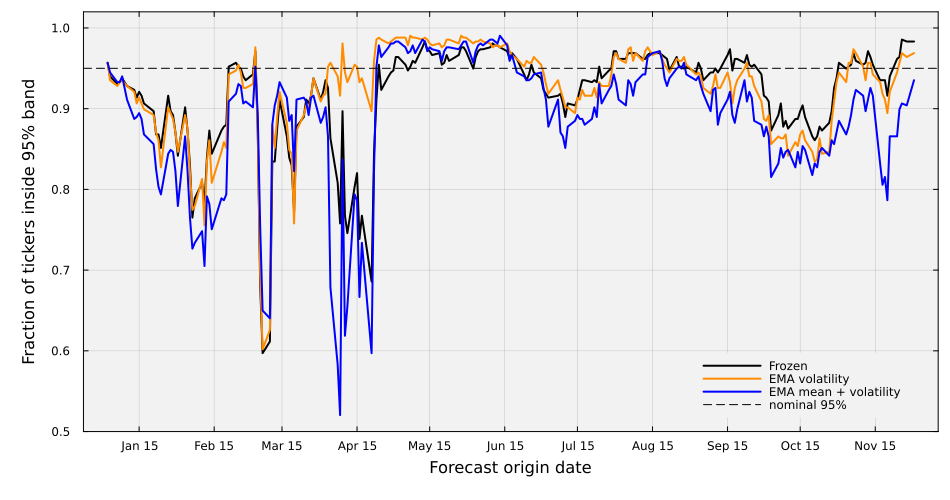

In [11]:
# Score the 95% growth-rate bands against the later observed growth rates -
coverage_summary = combine(groupby(rolling_results, :method),
    :covered_95 => mean => :coverage, :interval_width => mean => :width);
coverage_summary = coverage_summary[indexin(method_order, coverage_summary.method), :];
pretty_table(Matrix(select(coverage_summary, :method, :coverage, :width));
    column_labels=["Method", "95% coverage", "Band width (1/year)"],
    formatters=[fmt__printf("%.3f", 2:3)], fit_table_in_display_horizontally=false);

let
    # Fraction of tickers inside the band on each forecast date -
    coverage_by_date = combine(groupby(rolling_results, [:origin_date, :method]), :covered_95 => mean => :coverage);
    colors = [:black, :darkorange, :blue];
    origin_ticks = ticks_through(Date(maximum(coverage_by_date.origin_date)));
    p = plot(; xlabel="Forecast origin date", ylabel="Fraction of tickers inside 95% band", ylim=(0.5,1.02), xticks=origin_ticks,
        legend=:bottomright, size=(950,500), left_margin=8Plots.mm, bottom_margin=8Plots.mm,
        bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent);
    for (method,color) in zip(method_order, colors)
        rows = sort(coverage_by_date[coverage_by_date.method .== method, :], :origin_date);
        plot!(p, Date.(rows.origin_date), rows.coverage; label=method, c=color, lw=2);
    end
    hline!(p, [0.95]; c=:black, ls=:dash, label="nominal 95%");
    savefig(p, joinpath(_PATH_TO_FIGS,"L5a-coverage-by-date.png"));
    p
end


__What do we see?__ The three methods agree until the market moves, and then they separate.
* __Before the drop__: Forecasts made in early March miss for every method. Nothing anticipates the April drop, so no update can help with it.
* __After the drop__: The frozen band, whose width never changes, covers far fewer tickers than the EMA-volatility band, which widened as the shock entered the variance update. This is where updating pays off.
* __Updating the mean__: The EMA mean + volatility band covers the least in most months. The updated mean growth is noisy, and that noise shifts the band away from where the observations land.

Updating volatility improves the forecast distribution when the regime changes; updating mean growth does not, because a month of data cannot pin down the mean. Overlapping windows and shared market movements make these outcomes dependent, so treat this as a description of 2025 rather than a significance test; the 21-day half-life was chosen before inspecting these results.


___

## Summary
In this example, we initialized an EMA from the 2014–2024 GBM estimates, updated it using observed 2025 prices, and compared its forecasts with the frozen model.

> __Key Takeaways:__
>
> * **Exponential parameter updates:** We updated the mean and variance of observed growth rates, then recovered GBM volatility and arithmetic drift from those moments. We compared half-lives of 1, 5, 21, and 63 observations on the same 2025 prices: the shorter the half-life, the faster the estimates responded to the April shock and the more day-to-day noise they carried. The default 21-observation half-life is the one we carried into the forecast comparison.
> * **Forecasts from the available observations:** We used each day's estimates to simulate prices and calculate a target probability over the next chosen window. Parameters stayed fixed within each forecast, while both frozen and EMA probabilities changed as prices and prospective sale dates changed.
> * **Measured forecast improvement:** We checked the 95% prediction bands of the three methods against the later observed growth rates. Updating volatility kept coverage near its nominal level after the April shock, while updating the noisy mean growth lowered it, so a changing estimate does not by itself produce a better forecast.

Changing the half-life changes the balance between responding to recent observations and smoothing their noise. Its value should be chosen before evaluating the resulting forecasts.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
